# MNIST Granger-Pruning Pipeline
Interactive walkthrough of all 8 pipeline stages.

In [6]:
!unzip -qq /content/src.zip -d /content/

replace /content/src/config.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: o
error:  invalid response [o]
replace /content/src/config.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/src/data.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: [n]o
error:  invalid response [[n]o]
replace /content/src/data.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [7]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))

import torch
import src
from src.config import RESULTS, MODELS, EPOCHS_BASELINE, EPOCHS_FINETUNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
src.set_seed()
print(f'Device: {device}')

Device: cuda


## 1. Load Data

In [8]:
train_loader, test_loader = src.get_loaders()
print(f'Train batches: {len(train_loader)}  Test batches: {len(test_loader)}')

Train batches: 235  Test batches: 40


## 2. Baseline Model

In [9]:
model = src.MLP()
model.to(device)
print(f'Parameters: {model.count_parameters():,}')
print(model)

Parameters: 109,386
MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [10]:
history = src.train(model, train_loader, test_loader,
                    epochs=EPOCHS_BASELINE, device=device)
torch.save(model.state_dict(), MODELS / 'baseline.pt')

Epoch   1/10  train_loss=0.4034  train_acc=0.8855  val_loss=0.1920  val_acc=0.9433
Epoch   2/10  train_loss=0.1609  train_acc=0.9526  val_loss=0.1278  val_acc=0.9590
Epoch   3/10  train_loss=0.1136  train_acc=0.9661  val_loss=0.1087  val_acc=0.9654
Epoch   4/10  train_loss=0.0852  train_acc=0.9740  val_loss=0.0955  val_acc=0.9705
Epoch   5/10  train_loss=0.0677  train_acc=0.9797  val_loss=0.0845  val_acc=0.9741
Epoch   6/10  train_loss=0.0562  train_acc=0.9825  val_loss=0.0833  val_acc=0.9730
Epoch   7/10  train_loss=0.0451  train_acc=0.9864  val_loss=0.0808  val_acc=0.9755
Epoch   8/10  train_loss=0.0387  train_acc=0.9883  val_loss=0.0787  val_acc=0.9762
Epoch   9/10  train_loss=0.0297  train_acc=0.9912  val_loss=0.0784  val_acc=0.9760
Epoch  10/10  train_loss=0.0267  train_acc=0.9915  val_loss=0.0828  val_acc=0.9767


In [11]:
src.plot_training_curves(history)

[plot] training_curves → /content/results/training_curves.png


## 3. Activation Logging

In [12]:
src.log_activations(model, train_loader, device, max_steps=200)

import pandas as pd
act_df = pd.read_csv(RESULTS / 'activations.csv')
print(act_df.shape)
act_df.head()

[activation_log] saved 200 steps → /content/results/activations.csv
(200, 204)


,step,loss,hidden_0_n0,hidden_0_n1,hidden_0_n2,hidden_0_n3,hidden_0_n4,hidden_0_n5,hidden_0_n6,hidden_0_n7,...,logit_0,logit_1,logit_2,logit_3,logit_4,logit_5,logit_6,logit_7,logit_8,logit_9
0,0,0.019422,-0.719575,-1.023044,-0.621153,0.580346,-0.825654,1.347569,1.456605,-3.080696,...,-5.359595,-3.760665,-1.544363,-1.344136,-7.493357,-2.641586,-6.003170,-3.213094,-2.724899,-1.550515
1,1,0.052009,-0.790653,-0.675760,-0.496942,0.333761,-0.724159,1.646379,1.295291,-3.041691,...,-5.258848,-4.266813,-1.712518,-1.218566,-7.034881,-2.217228,-6.395797,-2.848017,-2.930642,-0.967179
2,2,0.023384,-0.399660,-1.163787,-0.371792,0.419312,-0.956819,1.258100,1.152547,-3.094294,...,-5.293978,-3.129562,-1.531368,-2.092709,-6.458914,-2.822596,-5.178126,-3.646411,-2.846820,-1.647725
3,3,0.032224,-1.020288,-0.937340,-1.164362,0.266198,-1.055226,2.028682,1.207597,-3.089775,...,-5.468266,-4.404973,-1.475365,-1.351868,-6.773871,-2.547283,-6.018793,-3.118666,-2.704745,-1.627131
4,4,0.045467,-0.390687,-1.115098,-0.715042,0.011390,-1.186913,1.351585,1.141716,-3.145589,...,-5.158263,-3.789242,-2.062639,-2.519972,-4.990347,-3.373749,-5.026922,-3.899775,-3.225981,-1.349049


## 4. Granger Causality

[granger] computing 192×192 matrix on 200 timesteps …
[granger] saved 192×192 matrix → /content/results/granger_matrix.csv
[plot] granger_heatmap → /content/results/granger_heatmap.png


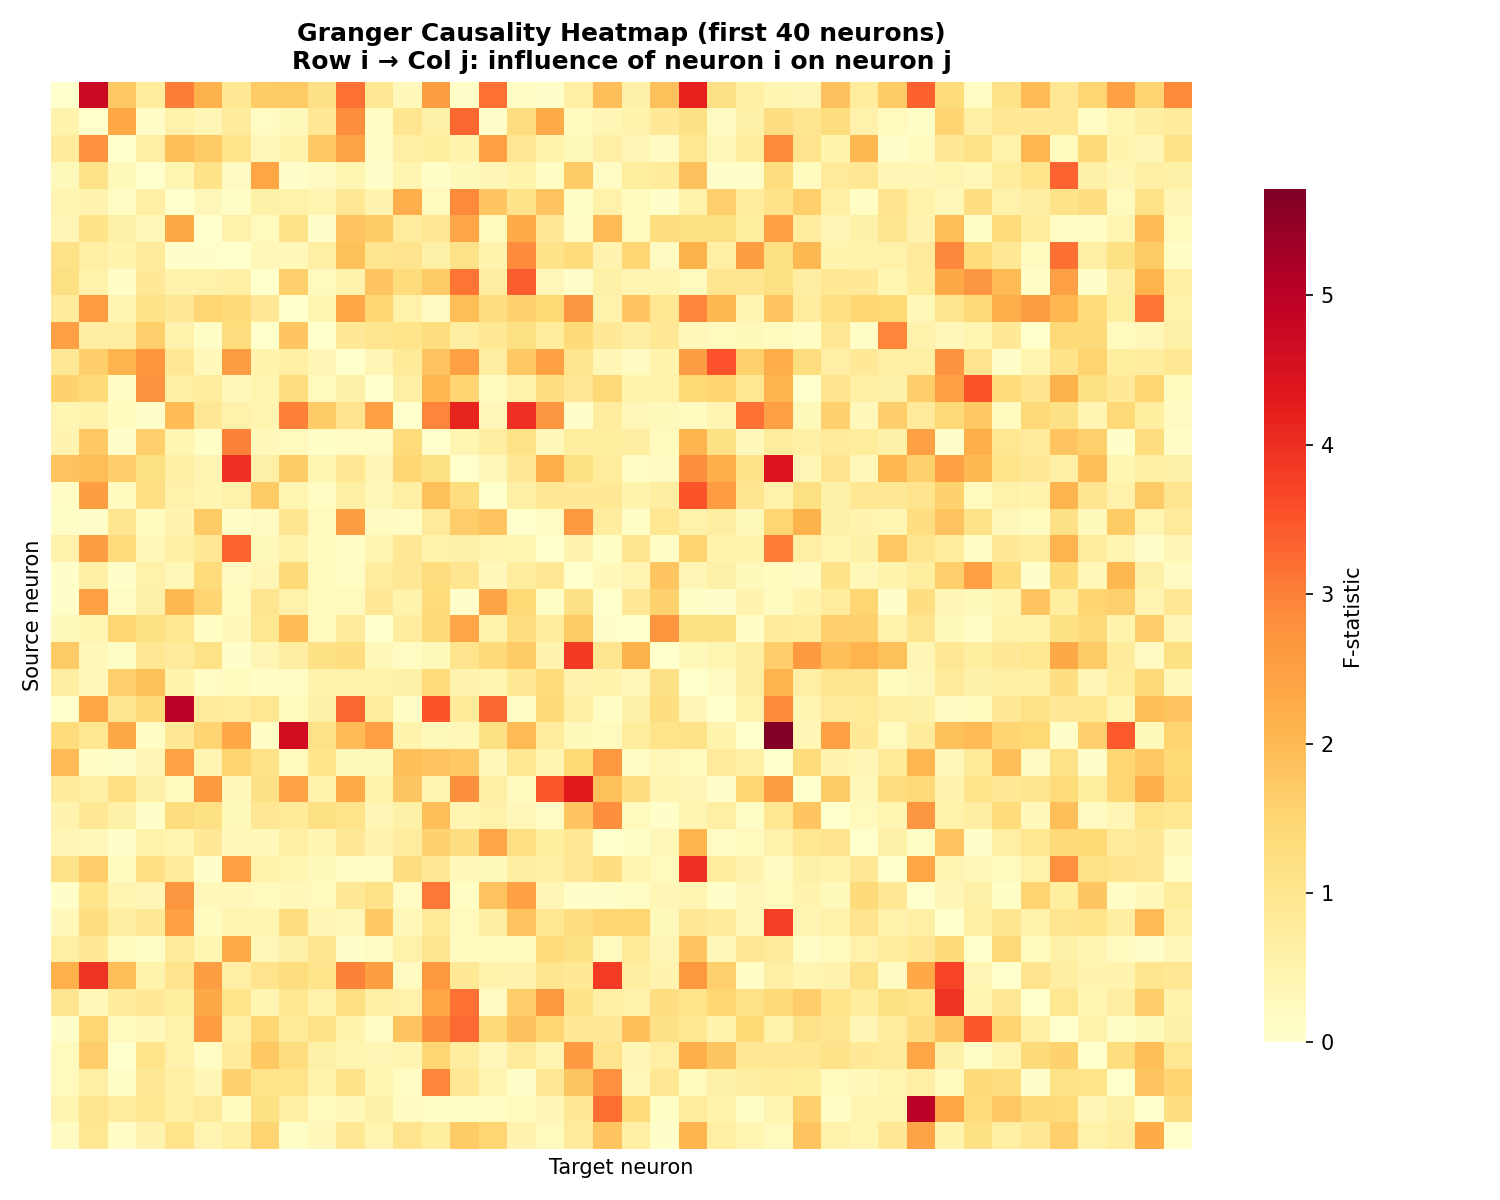

In [13]:
granger_df = src.compute_granger_matrix()
src.plot_granger_heatmap()

from IPython.display import Image
Image(str(RESULTS / 'granger_heatmap.png'))

## 5. Importance Scores

In [14]:
importance = src.compute_importance(model)
for name, scores in importance.items():
    print(f'{name}: mean={scores.mean():.4f}')

hidden_0: mean=0.4738
hidden_1: mean=0.5106


## 6–7. Prune + Retrain

In [15]:
import copy

metrics_rows = [src.evaluate_full(model, test_loader, device, label='baseline')]

for pct in [10, 20, 30, 40, 50]:
    m = copy.deepcopy(model)
    pruned, keep = src.prune_model(m, prune_pct=pct, importance=importance)
    pruned.to(device)
    src.train(pruned, train_loader, test_loader,
              epochs=EPOCHS_FINETUNE, device=device, verbose=False)
    row = src.evaluate_full(pruned, test_loader, device, label=f'pruned_{pct}')
    metrics_rows.append(row)
    print(f'Pruned {pct}% → acc={row["accuracy"]:.4f}  params={row["n_params"]:,}')

src.save_metrics(metrics_rows)

Pruned 10% → acc=0.9764  params=98,436
Pruned 20% → acc=0.9758  params=86,793
Pruned 30% → acc=0.9766  params=75,205
Pruned 40% → acc=0.9743  params=63,887
Pruned 50% → acc=0.9735  params=52,650
[metrics] saved 6 rows → /content/results/metrics.csv


## 8. Visualize Results

[plot] accuracy_vs_pruning → /content/results/accuracy_vs_pruning.png


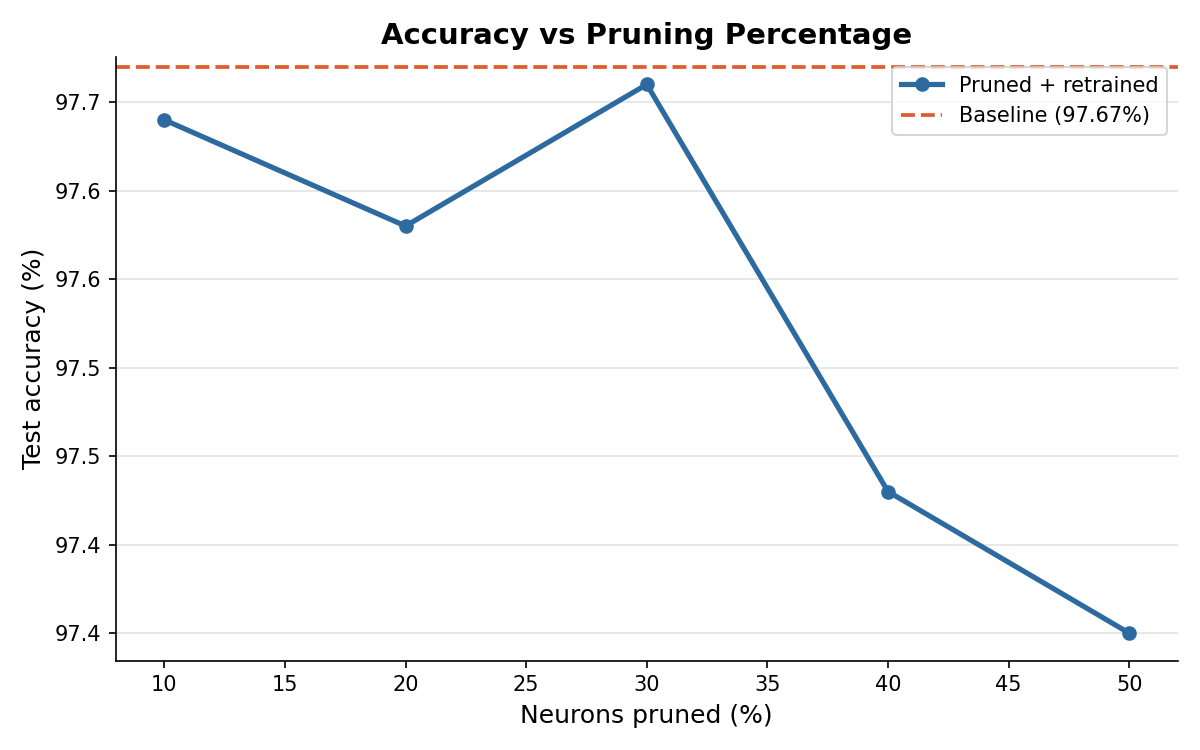

In [16]:
src.plot_accuracy_vs_pruning()
Image(str(RESULTS / 'accuracy_vs_pruning.png'))

In [17]:
pd.read_csv(RESULTS / 'metrics.csv')

,label,accuracy,n_params,model_size_kb,inference_ms
0,baseline,0.9767,109386,430.38,0.127
1,pruned_10,0.9764,98436,387.50,0.131
2,pruned_20,0.9758,86793,342.00,0.125
3,pruned_30,0.9766,75205,296.75,0.130
4,pruned_40,0.9743,63887,252.50,0.131
5,pruned_50,0.9735,52650,208.75,0.130


In [18]:
!zip -r output.zip /content/src /content/results /content/data

  adding: content/src/ (stored 0%)
  adding: content/src/data.py (deflated 60%)
  adding: content/src/granger.py (deflated 57%)
  adding: content/src/evaluation.py (deflated 53%)
  adding: content/src/config.py (deflated 70%)
  adding: content/src/__init__.py (deflated 58%)
  adding: content/src/pruning.py (deflated 66%)
  adding: content/src/__pycache__/ (stored 0%)
  adding: content/src/__pycache__/model.cpython-312.pyc (deflated 43%)
  adding: content/src/__pycache__/config.cpython-312.pyc (deflated 39%)
  adding: content/src/__pycache__/evaluation.cpython-312.pyc (deflated 38%)
  adding: content/src/__pycache__/data.cpython-312.pyc (deflated 38%)
  adding: content/src/__pycache__/granger.cpython-312.pyc (deflated 38%)
  adding: content/src/__pycache__/__init__.cpython-312.pyc (deflated 32%)
  adding: content/src/__pycache__/pruning.cpython-312.pyc (deflated 42%)
  adding: content/src/__pycache__/trainer.cpython-312.pyc (deflated 49%)
  adding: content/src/__pycache__/visualization.